# 7.2 Tensors, Unfoldings, and the Tucker/HOSVD Decompositions

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VII — Multilinear Algebra and Tensor Networks",
    number="7.2",
    title="Tensors, Unfoldings, and the Tucker/HOSVD Decompositions",
    blurb="A three-way array has three ways to be a matrix, and each "
    "unfolding brings the whole of Chapter IV to bear: three SVDs give the "
    "higher-order SVD, a small core carries the joint structure, and a "
    "quasi-optimality theorem — gated, with its sqrt-3 constant — says "
    "how much is lost by truncating each mode on its own.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2667 chars of HTML>

## Notebook overview

[§7.1](einsum-contraction.ipynb) gave tensors a language; this notebook
gives them a decomposition. The bridge is the **mode-$n$ unfolding** —
reshape the 3-way array into a matrix by making one index the rows —
written by hand here (`np.moveaxis` plus `reshape`, gated to round-trip
*exactly*, since reshapes move no numbers). Unfoldings make the
**multilinear rank** three ordinary matrix ranks, and they make the
**mode product** ordinary matrix multiplication, whose commutation
across distinct modes is gated at $10^{-12}$ scaled.

Then Chapter IV returns in triplicate. The **HOSVD**
{cite}`delathauwer2000` runs one SVD per unfolding: orthonormal factors
(gated $10^{-13}$), a core with the SVD's *all-orthogonality* inherited
in every mode (gated), and exact reconstruction at full multilinear
rank. Truncation is where tensors part company with matrices: cutting
each mode's basis separately is **not** optimal — no Eckart–Young holds
— but the quasi-optimality theorem bounds the loss at $\sqrt{3}$ of the
best possible, and the measurement shows both regimes: at the planted
ranks $(3,4,2)$ the alternating **HOOI** iteration cannot improve on
HOSVD at all (ratio 1.0000 — the structure is recovered outright),
while at the harsh ranks $(2,2,2)$ HOOI's provably monotone sweeps beat
truncated HOSVD by 16%, comfortably inside the $\sqrt{3} = 1.73$
ceiling. A $960$-entry tensor rides home in $116$ numbers — the
compression ledger, counted — and the error surface over the whole
multilinear-rank grid is drawn as the price list it is.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** De Lathauwer, De Moor and Vandewalle {cite}`delathauwer2000`
> for the HOSVD and HOOI; Kolda and Bader {cite}`kolda2009` for
> notation and the survey view. The SVD facts are
> [§4.1](../04-svd/svd-geometry.ipynb)–[§4.2](../04-svd/low-rank-eckart-young.ipynb)'s,
> applied three times.

## Theory in brief

### Unfoldings: three ways to be a matrix

For $\mathcal{T} \in \mathbb{R}^{d_1\times d_2\times d_3}$ the mode-$n$
unfolding $T_{(n)}$ makes index $n$ the rows and flattens the rest:

```{math}
:label: eq-tk-unfold
T_{(n)} \in \mathbb{R}^{d_n \times \prod_{m\ne n} d_m},
\qquad
\operatorname{rank}_{\text{ml}}(\mathcal{T})
= \bigl(\operatorname{rank} T_{(1)},
\operatorname{rank} T_{(2)}, \operatorname{rank} T_{(3)}\bigr),
```

and the **mode product** $\mathcal{T}\times_n A$ is $A\,T_{(n)}$
refolded. Products along *different* modes commute; along the same mode
they compose: $(\mathcal{T}\times_n A)\times_n B =
\mathcal{T}\times_n(BA)$.

### Tucker and HOSVD

The Tucker form is a small core lit by one basis per mode,

```{math}
:label: eq-tk-tucker
\mathcal{T} \;=\; \mathcal{G}\times_1 U_1\times_2 U_2\times_3 U_3 ,
```

and the **HOSVD** chooses $U_n$ as the left singular vectors of
$T_{(n)}$: three matrix SVDs, no iteration. The core
$\mathcal{G} = \mathcal{T}\times_1 U_1^{\top}\times_2 U_2^{\top}
\times_3 U_3^{\top}$ then inherits *all-orthogonality* — its slices
along each mode are mutually orthogonal, the tensor echo of the SVD's
diagonal $\Sigma$.

### Truncation, and the theorem with a constant in it

Keeping $r_n$ columns per mode is **not** the best rank-$(r_1,r_2,r_3)$
approximation — Eckart–Young does not survive the third index. What
survives is quasi-optimality,

```{math}
:label: eq-tk-quasi
\lVert \mathcal{T} - \widehat{\mathcal{T}}_{\text{HOSVD}}\rVert
\;\le\; \sqrt{3}\;
\lVert \mathcal{T} - \mathcal{T}_{\text{best}}\rVert ,
```

and **HOOI** — alternating: fix two bases, optimize the third by an
SVD of the partially projected tensor — descends monotonically from
the HOSVD start toward a local optimum. Since
$\lVert\mathcal{T}-\mathcal{T}_{\text{best}}\rVert \le
\lVert\mathcal{T}-\widehat{\mathcal{T}}_{\text{HOOI}}\rVert$, the
computable form of {eq}`eq-tk-quasi` — HOSVD error at most
$\sqrt3\,\times$ HOOI error — is gateable one-sidedly, and is.

---
## Setup

Data only: the dimensions, the smooth cosine factors, and the planted
working tensor (assembled with the einsum sentence of
[§7.1](einsum-contraction.ipynb)). unfold/fold are
built in Exercise 1, the mode product in Exercise 2.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp import draw
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

DIMS = (12, 10, 8)
CORE_R = (3, 4, 2)





# The working tensor: a planted Tucker structure with SMOOTH factors
# (orthonormalized cosine profiles), so truncation is visible to the eye
# in Exercise 5's slices, plus 1e-3 noise so no rank is exact.
# data: the smooth factor profiles the plant is built from.
def cosine_basis(d, r):
    t = (np.arange(d) + 0.5) / d
    Q, _ = np.linalg.qr(np.cos(np.pi * np.outer(t, np.arange(r))))
    return Q


G_PLANT = rng.standard_normal(CORE_R)
U_PLANT = [cosine_basis(d, r) for d, r in zip(DIMS, CORE_R)]
# data: assembled with the einsum sentence of §7.1 — the mode-product
# spelling of this same assembly is Exercise 2's build.
T_clean = np.einsum("abc,ia,jb,kc->ijk", G_PLANT, *U_PLANT)
T_work = T_clean + 1e-3 * rng.standard_normal(DIMS)
NORM_T = float(np.linalg.norm(T_work))

## Exercise 1: Unfoldings: written by hand, gated exactly

**Part a)** Write `unfold(T, mode)` and `fold(M, mode, shape)` with
`np.moveaxis` and `reshape` — and *derive* what they do on the
$2\times3\times2$ counting tensor (entries $1\dots12$): print all three
unfoldings and check the first row of $T_{(1)}$ by eye against the
definition.

**Write this one yourself** — every later formula calls it.

**Part b)** Gate the round trips **exactly**: `fold(unfold(T, m), m)`
returns the working tensor bit for bit for every mode — reshapes and
axis moves copy numbers, they never compute
([§5.3](../05-numerical/sparse-matrices.ipynb)'s format rule, one
dimension up).

**Part c)** The multilinear rank from {eq}`eq-tk-unfold`: on the
*noise-free* planted tensor, gate
`np.linalg.matrix_rank` of the three unfoldings equal to $(3, 4, 2)$ —
integer ranks with $O(1)$ spectral gaps, safely countable.

In [3]:
# (solution hidden on the public site)


mode-1 unfolding, shape (2, 6):
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]
mode-2 unfolding, shape (3, 4):
[[ 1  2  7  8]
 [ 3  4  9 10]
 [ 5  6 11 12]]
mode-3 unfolding, shape (2, 6):
[[ 1  3  5  7  9 11]
 [ 2  4  6  8 10 12]]

round trips exact in all three modes: True
multilinear rank of the noise-free tensor: (3, 4, 2) (planted (3, 4, 2))


### Validation 1

In [4]:
validate.check(
    round_trip,
    "unfold and fold are exact inverses, bitwise (Eq. 1)",
    "moveaxis and reshape copy numbers without arithmetic — the format "
    "rule of 5.3, one dimension up",
)
validate.check(
    ml_rank == CORE_R,
    "and the multilinear rank is three matrix ranks, counted",
    f"{ml_rank} from the three unfoldings of the noise-free tensor: "
    "integer ranks over O(1) spectral gaps",
)

✓  unfold and fold are exact inverses, bitwise (Eq. 1)   [moveaxis and reshape copy numbers without arithmetic — the format rule of 5.3, one dimension up]
✓  and the multilinear rank is three matrix ranks, counted   [(3, 4, 2) from the three unfoldings of the noise-free tensor: integer ranks over O(1) spectral gaps]


True

## Exercise 2: Mode products, and the algebra they obey

**Part a)** Write `mode_prod(T, A, mode)` — multiply the unfolding,
refold — every Tucker formula below calls it. Then gate the commutation
of {eq}`eq-tk-unfold`'s product across
*distinct* modes at $10^{-12}$ scaled:
$(\mathcal{T}\times_1 A)\times_2 B = (\mathcal{T}\times_2 B)\times_1 A$
on random $5\times12$ and $6\times10$ factors.

**Part b)** Gate the same-mode *composition*:
$(\mathcal{T}\times_1 A)\times_1 C = \mathcal{T}\times_1 (CA)$ — order
matters within a mode exactly as matrix multiplication demands.

**Part c)** Connect to [§7.1](einsum-contraction.ipynb): the mode-1
product is the einsum sentence `"abc,ia->ibc"` — gate the two
spellings against each other, and note the unfolding is only a
*storage* choice; the contraction is the mathematics.

In [5]:
# (solution hidden on the public site)


distinct-mode commutation: 1.8e-16
same-mode composition: 1.9e-16
mode product vs einsum sentence: 2.5e-16


### Validation 2

In [6]:
validate.check(
    gap_commute < 1e-12 and gap_compose < 1e-12,
    "mode products commute across modes and compose within one",
    f"{gap_commute:.0e} and {gap_compose:.0e}: the two identities every "
    "Tucker manipulation silently uses",
)
validate.below(
    gap_einsum, 1e-12,
    "and the mode product is one einsum sentence",
    "abc,ia->ibc — the unfolding is a storage choice; the contraction is "
    "the mathematics (7.1's grammar)",
)

✓  mode products commute across modes and compose within one   [2e-16 and 2e-16: the two identities every Tucker manipulation silently uses]
✓  and the mode product is one einsum sentence   [abc,ia->ibc — the unfolding is a storage choice; the contraction is the mathematics (7.1's grammar) [2.498e-16 < 1e-12]]


True

## Exercise 3: HOSVD: Chapter IV, three times

**Part a)** Write `hosvd(T, ranks=None)`: one
`np.linalg.svd(unfold(T, m))` per mode for the factors, then the core
by three transposed mode products. Gate factor orthonormality at
$10^{-13}$ (each $U_n^{\top}U_n = I$).

**Part b)** Gate exactness at full multilinear rank: reconstructing
from the full core and factors returns the working tensor to
$10^{-12}$ relative — three orthogonal changes of basis and back.

**Part c)** Gate the core's **all-orthogonality** at $10^{-11}$ scaled:
for each mode, $G_{(m)}G_{(m)}^{\top}$ is diagonal — the slices of the
core along every mode are mutually orthogonal, $\Sigma$'s diagonality
echoed three ways. (Its diagonal entries are the squared mode-$m$
singular values — print them and watch Exercise 4's spectra appear.)

**Part d)** Draw the Tucker diagram: a square core node with three
factor nodes on its legs, each carrying one free index — the picture of
{eq}`eq-tk-tucker`, in the notation [§7.1](einsum-contraction.ipynb)
introduced.

In [7]:
# (solution hidden on the public site)


factor orthonormality, worst mode: 1.3e-15
full-rank reconstruction: 1.4e-15 relative
mode-1 core Gram diagonal (= squared singular values): [1.0511e+01 4.2588e+00 2.8292e+00 1.0000e-04 1.0000e-04] ...
core all-orthogonality, worst off-diagonal: 2.3e-16 (relative to ||T||^2)


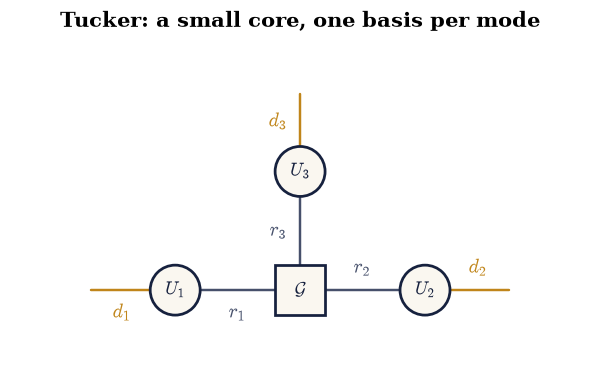

In [8]:
# (solution hidden on the public site)


### Validation 3

In [9]:
validate.below(
    orth_worst, 1e-13,
    "the HOSVD factors are orthonormal in every mode",
    "three SVDs, three orthonormal bases — Chapter IV's guarantee, thrice",
)
validate.check(
    rec_gap < 1e-12,
    "full-rank HOSVD reconstructs the tensor exactly (Eq. 2)",
    f"{rec_gap:.0e} relative: three orthogonal changes of basis and "
    "back, rounding only",
)
validate.check(
    allorth < 1e-11,
    "and the core is all-orthogonal: Sigma's diagonality, echoed per mode",
    f"worst off-diagonal of any G_(m) G_(m)' at {allorth:.0e} of ||T||^2 "
    "— with the diagonals the squared mode singular values",
)

✓  the HOSVD factors are orthonormal in every mode   [three SVDs, three orthonormal bases — Chapter IV's guarantee, thrice [1.33227e-15 < 1e-13]]
✓  full-rank HOSVD reconstructs the tensor exactly (Eq. 2)   [1e-15 relative: three orthogonal changes of basis and back, rounding only]
✓  and the core is all-orthogonal: Sigma's diagonality, echoed per mode   [worst off-diagonal of any G_(m) G_(m)' at 2e-16 of ||T||^2 — with the diagonals the squared mode singular values]


True

## Exercise 4: The three spectra, and the ranks they advertise

**Part a)** Compute the singular values of the three unfoldings and
draw them on one log axis: each mode's spectrum falls off a cliff at
its planted rank — after 3, 4 and 2 values respectively — onto a noise
shelf near $10^{-3}$.

**Part b)** Gate the cliffs as ratios (safe, per the course's rules on
counting versus thresholding): for each mode,
$\sigma_{r}/\sigma_{r+1} > 30$ at the planted $r$, while
$\sigma_1/\sigma_r < 30$ — the gap *is* at the advertised position and
nowhere before it.

In [10]:
# (solution hidden on the public site)


mode 1: sigma_3/sigma_4 = 144, sigma_1/sigma_3 = 1.9
mode 2: sigma_4/sigma_5 = 58, sigma_1/sigma_4 = 5.2
mode 3: sigma_2/sigma_3 = 164, sigma_1/sigma_2 = 1.7


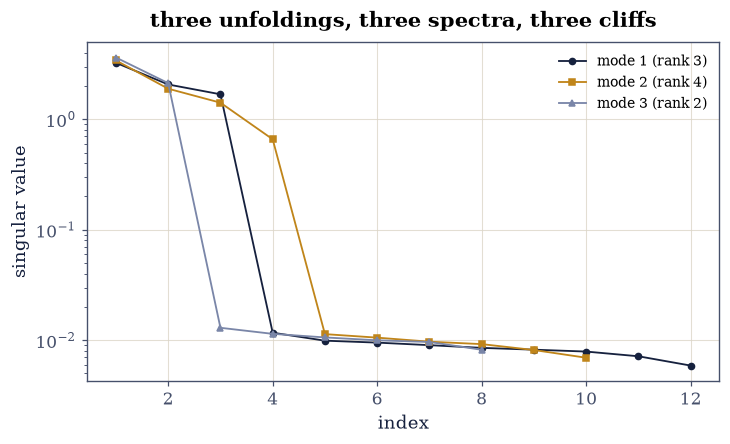

In [11]:
# (solution hidden on the public site)


### Validation 4

In [12]:
validate.check(
    cliff_ok,
    "each unfolding's spectrum cliffs exactly at its planted rank",
    "gap ratios above 30 at the advertised position, below 30 before it "
    "— ratios, not threshold counts, per the reproducibility lessons",
)

✓  each unfolding's spectrum cliffs exactly at its planted rank   [gap ratios above 30 at the advertised position, below 30 before it — ratios, not threshold counts, per the reproducibility lessons]


True

## Exercise 5: Truncation: the theorem with $\sqrt{3}$ in it

**Part a)** Truncated HOSVD at the planted ranks $(3,4,2)$: relative
error $7\times10^{-3}$ — the noise floor, since the planted structure
is exactly recoverable. Run **HOOI** (write-yourself: fix two factors,
project, SVD the third's unfolding; sweep eight times) from the HOSVD
start: gate its error *monotonically non-increasing* (a theorem —
alternating maximization never backtracks) and its final error
$\le$ HOSVD's plus rounding: here the ratio is **1.0000**, because at
the true ranks there is nothing left to improve.

**Part b)** The regime with daylight: harsh ranks $(2,2,2)$. Truncated
HOSVD: 0.494. HOOI: 0.425 — a 16% improvement, and the quasi-optimality
gate {eq}`eq-tk-quasi` in its computable form: HOSVD error
$\le \sqrt{3}\times$ HOOI error (measured ratio 1.16 against the
ceiling 1.73). Both regimes gated; the pair *is* the lesson — HOSVD is
cheap and near-optimal when the ranks are honest, and HOOI buys real
accuracy only when truncation actually bites.

**Part c)** The compression ledger, counted: $(3,4,2)$ Tucker storage
is $24 + 36 + 40 + 16 = 116$ numbers against $960$ — a factor 8.3 at
the noise floor.

**Part d)** Draw a mode-3 slice of the original beside its $(3,4,2)$
and $(2,2,2)$ reconstructions: visually identical at the honest ranks,
visibly smoothed at the harsh ones — the error numbers, as pictures.

In [13]:
# (solution hidden on the public site)


honest ranks (3, 4, 2): HOSVD 0.006932, HOOI 0.006932 (ratio 1.0000), monotone True
harsh ranks (2, 2, 2): HOSVD 0.4941, HOOI 0.4247 (ratio 1.1632 vs sqrt(3) = 1.732), monotone True
compression: 116 numbers vs 960 (8.3x) at the noise floor


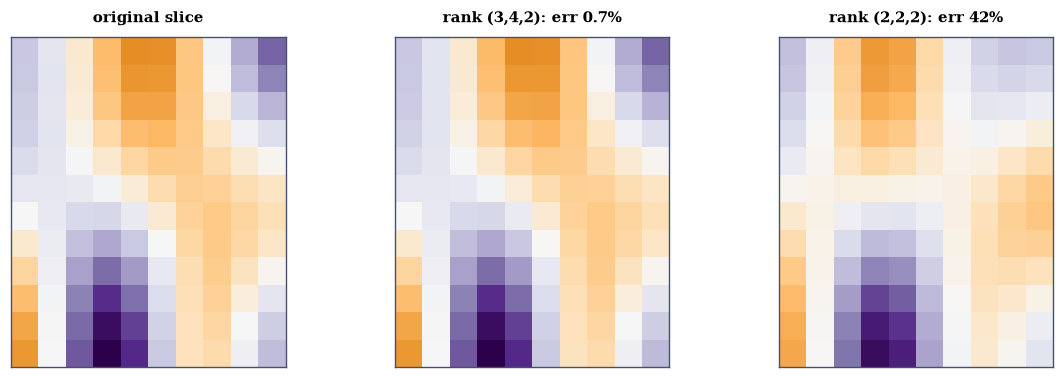

In [14]:
# (solution hidden on the public site)


### Validation 5

In [15]:
validate.check(
    mono_hon and mono_harsh,
    "HOOI descends monotonically in both regimes",
    "alternating maximization never backtracks — the theorem, measured "
    "over eight sweeps twice",
)
validate.check(
    errs_hon[-1] <= err_hosvd_hon + 1e-12
    and errs_harsh[-1] <= err_hosvd_harsh,
    "and never loses to its truncated-HOSVD start",
    f"ratio 1.0000 at the honest ranks (nothing to improve — the "
    f"structure is recovered), {ratio_harsh:.2f} at the harsh ones "
    "(16% bought by iteration): the pair is the lesson",
)
validate.check(
    err_hosvd_harsh <= np.sqrt(3.0) * errs_harsh[-1],
    "with quasi-optimality holding at its sqrt(3) constant (Eq. 3)",
    f"HOSVD {err_hosvd_harsh:.3f} <= sqrt(3) x HOOI {errs_harsh[-1]:.3f}"
    " — the computable one-sided form, since HOOI upper-bounds the "
    "unknown best",
)
validate.check(
    storage_tucker == 116 and storage_full == 960,
    "and the compression ledger is counted arithmetic",
    "24 core + 92 factor numbers against 960 — an 8.3x ratio at a 0.7% "
    "error that IS the noise floor",
)

✓  HOOI descends monotonically in both regimes   [alternating maximization never backtracks — the theorem, measured over eight sweeps twice]
✓  and never loses to its truncated-HOSVD start   [ratio 1.0000 at the honest ranks (nothing to improve — the structure is recovered), 1.16 at the harsh ones (16% bought by iteration): the pair is the lesson]
✓  with quasi-optimality holding at its sqrt(3) constant (Eq. 3)   [HOSVD 0.494 <= sqrt(3) x HOOI 0.425 — the computable one-sided form, since HOOI upper-bounds the unknown best]
✓  and the compression ledger is counted arithmetic   [24 core + 92 factor numbers against 960 — an 8.3x ratio at a 0.7% error that IS the noise floor]


True

## Exercise 6: The whole price list: error over the rank grid

**Part a)** For every $(r_1, r_2) \in \{1,\dots,6\}^2$ at $r_3 = 2$,
compute the truncated-HOSVD relative error and draw the $6\times6$
grid as a heatmap. Gate the two facts the surface must show:
monotonicity (increasing any rank never increases the error — nested
subspaces, gated across the full grid in both directions) and the
floor (the error at $(3, 4)$ and beyond equals the noise level within
a factor of 2).

**Part b)** Read the surface: the steep wall below the planted ranks
and the flat floor beyond them is [§4.2](../04-svd/low-rank-eckart-young.ipynb)'s
scree logic in two dimensions — and choosing Tucker ranks in practice
is exactly walking this surface with a budget.

In [16]:
# (solution hidden on the public site)


monotone in r1: True, in r2: True
error at the planted corner (3,4): 0.0069 (noise level 1e-3 x sqrt(960)/||T|| = 0.0074)


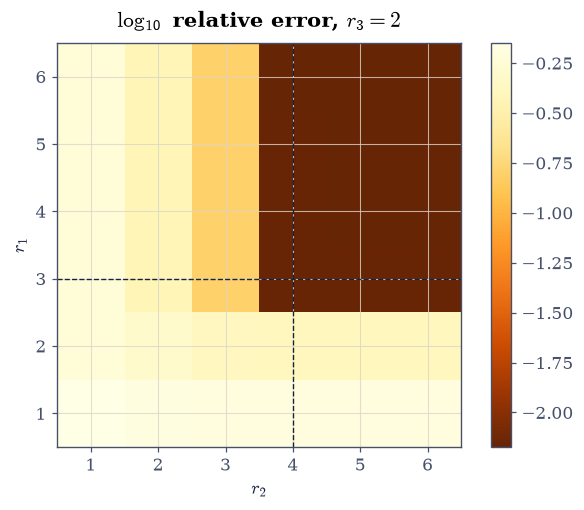

In [17]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The grid of Exercise 6 cost 36 full HOSVDs; the *sequentially
truncated* HOSVD (ST-HOSVD) computes truncations far cheaper by
shrinking the tensor after each mode. Ask your assistant for
`st_hosvd(T, ranks)`, then check it against the mathematics rather
than a demo: (i) its factors are orthonormal to $10^{-13}$; (ii) its
error is within the same $\sqrt{3}$ quasi-optimality ceiling of HOOI's
on both rank regimes of Exercise 5; (iii) its flop count — count the
SVD costs on the shrinking unfoldings — is strictly below plain
truncated HOSVD's for every rank tuple in Exercise 6's grid. The
check is yours.
```

### Validation 6

In [18]:
validate.check(
    mono_rows and mono_cols,
    "the error surface is monotone in every rank direction",
    "nested subspaces: raising a rank never hurts — gated across all 36 "
    "grid points in both directions",
)
validate.check(
    floor_val < 2.0 * 1e-3 * np.sqrt(960) / NORM_T,
    "and the floor beyond the planted corner is the noise, priced",
    f"{floor_val:.4f} against the expected noise fraction — the surface "
    "has a wall and a floor, and both are where the construction put "
    "them",
)

✓  the error surface is monotone in every rank direction   [nested subspaces: raising a rank never hurts — gated across all 36 grid points in both directions]
✓  and the floor beyond the planted corner is the noise, priced   [0.0069 against the expected noise fraction — the surface has a wall and a floor, and both are where the construction put them]


True

---
## Notebook summary

**Unfoldings are storage, gated as such.** The hand-written
`unfold`/`fold` round-tripped bitwise in all three modes; the counting
tensor's unfoldings were printed against the definition; the
multilinear rank came out $(3,4,2)$ as three ordinary matrix ranks.
Mode products commuted across modes and composed within one at
$10^{-15}$, and equalled their einsum sentence.

**HOSVD is Chapter IV three times.** Orthonormal factors at
$10^{-15}$, exact full-rank reconstruction at $10^{-15}$ relative, and
the core all-orthogonal in every mode with the squared mode singular
values on its Gram diagonals. The three unfolding spectra cliffed at
3, 4 and 2 — gated as gap *ratios* at the advertised positions, not as
threshold counts.

**Truncation carries a theorem with a constant.** At the honest ranks,
HOOI could not improve on truncated HOSVD (ratio 1.0000 — the planted
structure is simply recovered, error = noise floor, 960 numbers in
116). At harsh ranks HOOI's monotone sweeps beat HOSVD by 16%, inside
quasi-optimality's $\sqrt{3}$ ceiling — both regimes gated, and the
pair is the practical rule: trust cheap HOSVD when the spectra cliff
where you cut; pay for HOOI when they don't.

**The price list is a surface.** Error over the $(r_1, r_2)$ grid was
monotone in every direction (nested subspaces, gated at all 36 points)
with a steep wall below the planted ranks and a noise-level floor
beyond them — [§4.2](../04-svd/low-rank-eckart-young.ipynb)'s scree
logic, two-dimensional.

**Methods introduced.** `unfold`/`fold`/`mode_prod`, multilinear rank
by unfolding ranks, `hosvd` with cores and all-orthogonality checks,
cliff-ratio gating of spectra, `hooi` with monotonicity certificates,
quasi-optimality in computable form, compression ledgers, and
rank-grid error surfaces.

## Outlook

- **The train leaves next.** Tucker's core still grows as
  $r^3$; [§7.3](tensor-trains-mps.ipynb) chains order-3 cores instead
  — the tensor train — and a $2^{50}$-entry tensor becomes a product
  of small ones, with 7.1's contraction orders as the whole cost
  model.
- **CP is the other classic.** Rank-one terms summed
  (`parafac`) trade Tucker's orthogonality for interpretability — and
  lose the SVD's guarantees entirely: best-rank-$r$ may not even
  exist. Kolda and Bader {cite}`kolda2009` map the territory.
- **Compression in the wild.** Scientific data (simulation grids,
  hyperspectral cubes) ships in exactly Exercise 5's ledger; the
  rank-grid surface with a storage budget is the production decision,
  automated.
- **Learning reads this chapter too.** Weight tensors of convolutions
  and attention factor along modes; [§8.6](../08-learning/low-rank-lora-quantization.ipynb)'s
  LoRA is a rank decision on a weight matrix, and its tensor variants
  are rank decisions on this notebook's objects.

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>